# Source-forward comparison smoke test

This notebook compares the legacy event sampler with source-forward sampling. When source magnitude selection is configured, the isochrone/IMF selection is folded into the source-distance prior before sampling events.



In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_repo_root(start):
    for path in [start, *start.parents]:
        if (path / "CMakeLists.txt").exists() and (path / "build").exists():
            return path
    return start

repo_root = find_repo_root(Path.cwd().resolve())
build_dir = repo_root / "build"
if build_dir.exists():
    sys.path.insert(0, str(build_dir))

import genulens


## Simulation setup

The legacy run uses the historical LF source selection. The source-forward run uses PRIME isochrones plus the IMF to put an apparent `Imag` selection into the source-distance prior, then samples a concrete source star consistent with that selected prior.



In [2]:
N_SIMU = 2_000
SEED = 2026


def as_dataframe(result):
    return pd.DataFrame(result.to_numpy(), columns=result.columns)


def base_config():
    cfg = genulens.Config(l=1.0, b=-3.9, n_simu=N_SIMU, seed=SEED)
    cfg.source.i_min = 12.0
    cfg.source.i_max = 21.0
    cfg.source.extinction_mode = "genstars"
    cfg.source.extinction_law = 1
    cfg.source.ejk_rc = 1.0
    cfg.source.dm_rc = 14.5
    # AIrc would otherwise also activate the default lens-flux IL constraint.
    # This comparison is only about source selection and source-forward annotations.
    cfg.observation.IL_err = 0.0
    return cfg


def genstars_extlaw1_ai_rc(l_deg, b_deg, ejk_rc):
    if l_deg > 0.0 and b_deg > 0.0:
        ejk_ai = 3.65
    elif l_deg < 0.0 and b_deg > 0.0:
        ejk_ai = 3.77
    elif l_deg > 0.0 and b_deg < 0.0:
        ejk_ai = 3.97
    elif l_deg < 0.0 and b_deg < 0.0:
        ejk_ai = 3.82
    else:
        ejk_ai = 3.86
    return ejk_rc * ejk_ai


cfg_legacy = base_config()
legacy = genulens.simulate(cfg_legacy)
df_legacy = as_dataframe(legacy)

cfg_forward = base_config()
cfg_forward.forward_source.enabled = 1
cfg_forward.forward_source.photometry = "prime"
cfg_forward.forward_source.min_initial_mass_msun = 0.1
cfg_forward.forward_source.max_initial_mass_msun = 2.0
cfg_forward.forward_source.selection_bands = ["Imag"]
cfg_forward.forward_source.selection_min_magnitudes = [12.0]
cfg_forward.forward_source.selection_max_magnitudes = [21.0]

forward = genulens.simulate(cfg_forward)
df_forward = as_dataframe(forward)

# assert len(df_legacy) == N_SIMU
# assert len(df_forward) == N_SIMU

corner_columns = ["M_L", "D_L", "D_S", "mu_rel_N", "mu_rel_E"]
event_rows_identical = np.allclose(df_legacy[corner_columns], df_forward[corner_columns])
event_weights_identical = np.allclose(df_legacy["wtj"], df_forward["wtj"])
# assert event_rows_identical
# assert event_weights_identical

source_columns = ["M_S_ini", "M_S", "R_S", "teff_S", "logg_S", "theta_S", "M_Imag_S"]
finite_source = np.isfinite(df_forward[source_columns].to_numpy()).all(axis=1)
# assert finite_source.all()

ai_rc = genstars_extlaw1_ai_rc(cfg_forward.l, cfg_forward.b, cfg_forward.source.ejk_rc)
dmean = 10 ** (0.2 * cfg_forward.source.dm_rc) * 10
hscale = cfg_forward.source.dust_scale_height_pc / (abs(np.sin(np.deg2rad(cfg_forward.b))) + 0.0001)
ai0 = ai_rc / (1.0 - np.exp(-dmean / hscale))
ai = ai0 * (1.0 - np.exp(-df_forward["D_S"] / hscale))
apparent_i = df_forward["M_Imag_S"] + 5.0 * np.log10(0.1 * df_forward["D_S"]) + ai
# assert np.all((apparent_i[finite_source] >= 12.0) & (apparent_i[finite_source] <= 18.0))

pd.DataFrame(
    {
        "legacy_rows": [len(df_legacy)],
        "forward_rows": [len(df_forward)],
        "event_rows_identical": [event_rows_identical],
        "event_weights_identical": [event_weights_identical],
        "finite_source_fraction": [finite_source.mean()],
        "apparent_i_min": [apparent_i.min()],
        "apparent_i_max": [apparent_i.max()],
    }
)





genulens: building forward-source selection density grid (161 distance bins, 11 components, 1 band cut)...
genulens: forward-source selection density grid 10% complete
genulens: forward-source selection density grid 20% complete
genulens: forward-source selection density grid 30% complete
genulens: forward-source selection density grid 40% complete
genulens: forward-source selection density grid 50% complete
genulens: forward-source selection density grid 60% complete
genulens: forward-source selection density grid 70% complete
genulens: forward-source selection density grid 80% complete
genulens: forward-source selection density grid 90% complete
genulens: forward-source selection density grid complete (selected source weight 4.147163e+03, cache hits 161, misses 1610)


,legacy_rows,forward_rows,event_rows_identical,event_weights_identical,finite_source_fraction,apparent_i_min,apparent_i_max
0,2000,2000,False,False,1.0,13.15472,20.998359


In [3]:
df_legacy

,wtj,M_L,D_L,D_S,t_E,theta_E,pi_E,pi_EN,pi_EE,mu_rel,mu_rel_N,mu_rel_E,mu_Sl,mu_Sb,I_L,K_L,iS,iL,fREM
0,0.209433,0.110458,3540.037247,6593.494150,52.418714,0.343044,0.381345,0.168482,0.342108,2.390308,1.056060,2.144367,-3.532146,3.203521,27.760798,99.0,8.0,5.0,0.0
1,0.394723,0.567178,7035.555083,7459.767648,123.935430,0.193222,0.041832,-0.035557,0.022035,0.569443,-0.484035,0.299960,-3.275279,1.706211,25.484121,99.0,8.0,6.0,0.0
2,0.026564,0.265230,365.072936,1241.092187,15.911350,2.043583,0.946102,-0.654660,-0.683029,46.911080,-32.460369,-33.867003,2.220864,-2.075349,17.869924,99.0,4.0,5.0,0.0
3,0.813125,0.575708,8219.604664,8653.732321,11.757049,0.169160,0.036080,-0.026708,-0.024258,5.255218,-3.890145,-3.533282,-5.357983,-2.245424,25.846994,99.0,8.0,10.0,0.0
4,1.077671,1.063927,6324.278223,8481.836409,58.231686,0.590341,0.068133,-0.004606,0.067977,3.702830,-0.250339,3.694358,-5.663088,-0.589375,21.767205,99.0,8.0,8.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0.296735,0.254111,2277.715978,7126.212866,68.953080,0.786236,0.379923,0.347611,0.153324,4.164753,3.810545,1.680747,-5.101687,-1.099504,23.896865,99.0,8.0,2.0,0.0
1996,0.620666,0.069801,7782.281024,7977.560759,2.378097,0.042285,0.074387,-0.041881,0.061476,6.494508,-3.656547,5.367336,-5.470067,4.429855,36.046928,99.0,8.0,8.0,0.0
1997,0.274838,0.389751,5744.098242,7074.528604,21.091288,0.322364,0.101561,-0.019342,-0.099702,5.582563,-1.063176,-5.480389,-1.313372,-2.590862,26.005775,99.0,8.0,5.0,0.0
1998,1.016145,0.667659,4080.701931,7616.340960,28.828584,0.786479,0.144644,0.121566,0.078381,9.964460,8.374612,5.399661,-7.875647,-0.480804,22.714751,99.0,8.0,5.0,0.0


In [4]:
df_forward

,wtj,M_L,D_L,D_S,t_E,theta_E,pi_E,pi_EN,pi_EE,mu_rel,...,M_S,R_S,teff_S,logg_S,theta_S,M_Vmag_S,M_Imag_S,M_Jmag_2mass_S,M_Hmag_2mass_S,M_Ksmag_2mass_S
0,0.218438,0.110458,3570.160272,6658.446969,51.080778,0.341857,0.380025,0.172814,0.338459,2.444426,...,1.077614,2.300748,5070.155115,3.744622,1.606914,3.767533,2.801116,2.145611,1.680561,1.606105
1,0.394723,0.567178,7035.555083,7476.476061,126.066505,0.196770,0.042600,-0.035616,0.023372,0.570097,...,1.089000,4.570819,4822.030694,3.153289,2.843110,2.599261,1.534724,0.800504,0.271602,0.184284
2,0.026564,0.265230,365.072936,1241.772960,15.913139,2.043816,0.946210,-0.654725,-0.683116,46.911164,...,0.627614,0.612205,3846.692358,4.659354,2.292723,8.911001,6.947071,5.860412,5.183428,4.997461
3,0.813125,0.575708,8219.604664,8671.235936,12.048176,0.172363,0.036763,-0.027299,-0.024623,5.225312,...,1.003000,5.822224,4835.477256,2.907115,3.122515,2.049650,1.011551,0.280582,-0.253387,-0.336097
4,1.113686,1.063927,6341.454790,8500.278510,58.024144,0.589074,0.067987,-0.004475,0.067839,3.708097,...,1.027000,7.062345,4644.543236,2.748895,3.863780,1.911651,0.764359,-0.033218,-0.612080,-0.710438
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0.229047,0.446750,2288.827710,6704.268923,109.792097,1.023183,0.281226,0.279081,-0.034669,3.403867,...,0.890000,11.625068,4907.257463,2.254756,8.063817,0.445999,-0.542893,-1.252204,-1.768798,-1.846231
1996,0.813125,0.082442,6792.432742,8613.343513,21.193782,0.144556,0.215305,0.135591,0.167246,2.491261,...,1.058000,10.672067,4500.390622,2.403596,5.762001,1.242399,0.019321,-0.831238,-1.452147,-1.562537
1997,2.443349,1.033070,8026.211744,10567.401776,38.005030,0.502065,0.059676,0.032098,0.050309,4.825134,...,0.951000,10.233101,4706.510570,2.393990,4.503349,1.001495,-0.104010,-0.881515,-1.436515,-1.533515
1998,0.902143,0.554141,2995.975514,7741.455178,28.627345,0.960917,0.212928,0.156364,0.144529,12.260134,...,0.954380,24.205166,4336.760205,1.647747,14.540591,-0.295241,-1.553924,-2.468367,-3.136089,-3.258570


## Legacy vs source-forward event prior

This is the requested corner plot over `M_L`, `D_L`, `D_S`, `mu_rel_N`, and `mu_rel_E`. The source-forward run now uses the isochrone/IMF `Imag` selection in the source prior, so the event-level distribution is expected to differ from the legacy LF-only run.



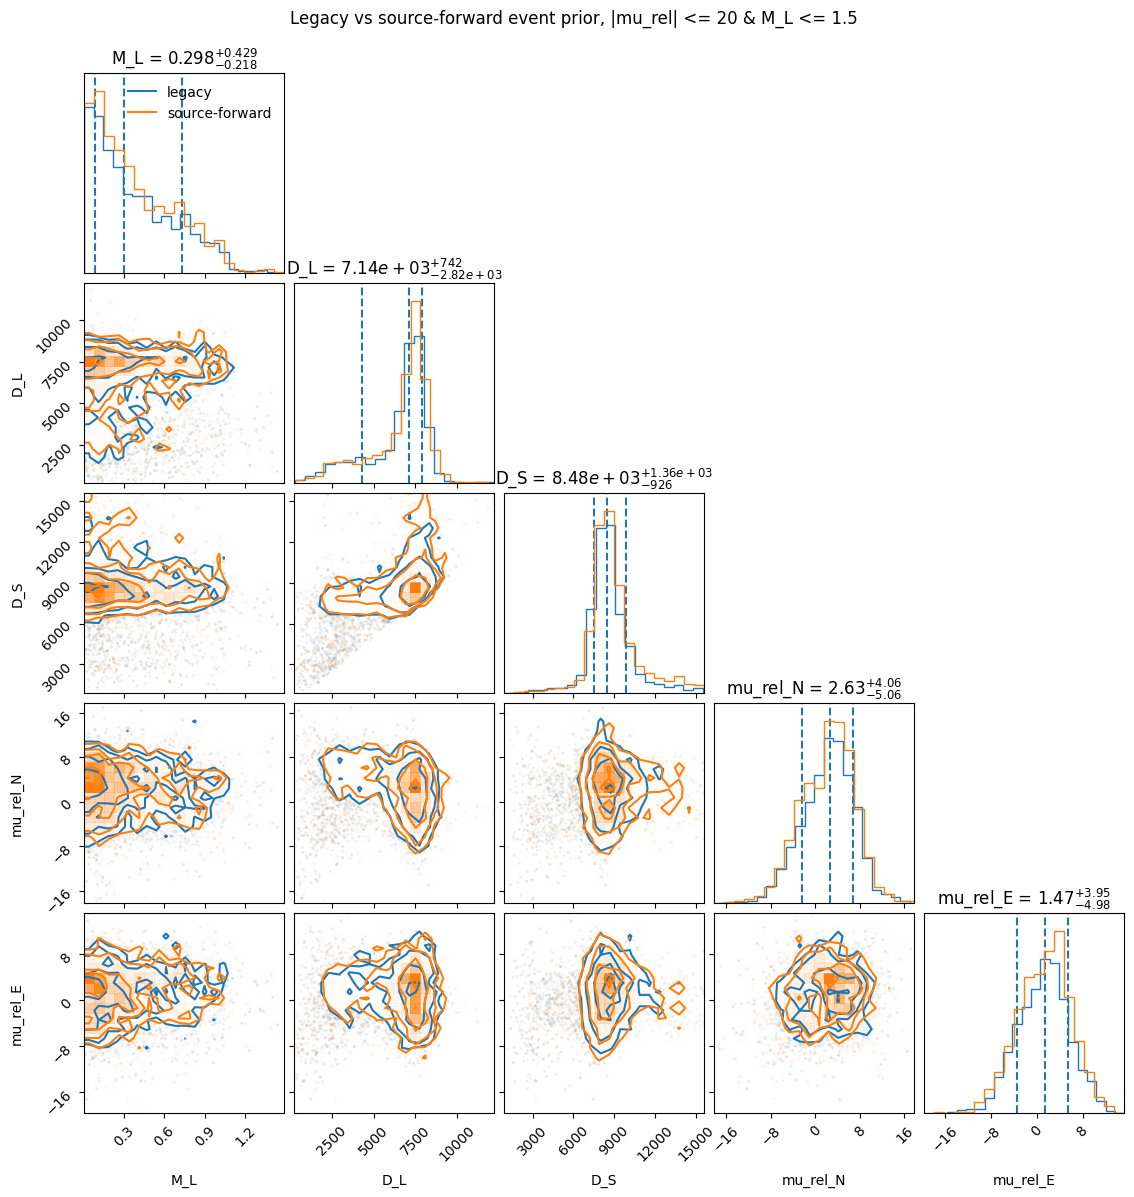

In [5]:
def event_corner_frame(df):
    mu_abs = np.sqrt(df["mu_rel_N"]**2 + df["mu_rel_E"]**2)
    return df[
        (mu_abs <= 20) &
        (df["M_L"] <= 1.5)
    ].copy()


df_legacy_corner = event_corner_frame(df_legacy)
df_forward_corner = event_corner_frame(df_forward)

try:
    import corner

    fig = corner.corner(
        df_legacy_corner[corner_columns].to_numpy(),
        labels=corner_columns,
        weights=df_legacy_corner["wtj"].to_numpy(),
        color="tab:blue",
        quantiles=[0.16, 0.50, 0.84],
        show_titles=True,
        title_fmt=".3g",
        label_kwargs={"fontsize": 10},
    )
    corner.corner(
        df_forward_corner[corner_columns].to_numpy(),
        labels=corner_columns,
        weights=df_forward_corner["wtj"].to_numpy(),
        color="tab:orange",
        fig=fig,
        show_titles=False,
    )
    fig.axes[0].plot([], [], color="tab:blue", label="legacy")
    fig.axes[0].plot([], [], color="tab:orange", label="source-forward")
    fig.axes[0].legend(frameon=False, loc="upper right")
except ImportError:
    fig, axes = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)
    pd.plotting.scatter_matrix(
        df_legacy_corner[corner_columns],
        ax=axes[0],
        diagonal="hist",
        alpha=0.05,
    )
    pd.plotting.scatter_matrix(
        df_forward_corner[corner_columns],
        ax=axes[1],
        diagonal="hist",
        alpha=0.05,
    )
    axes[0].set_title("legacy")
    axes[1].set_title("source-forward")

fig.suptitle("Legacy vs source-forward event prior, |mu_rel| <= 20 & M_L <= 1.5", y=1.02)
plt.show()


## Source-forward full corner

This plot includes the event-level quantities plus source physical properties needed by the forward source-prior workflow.


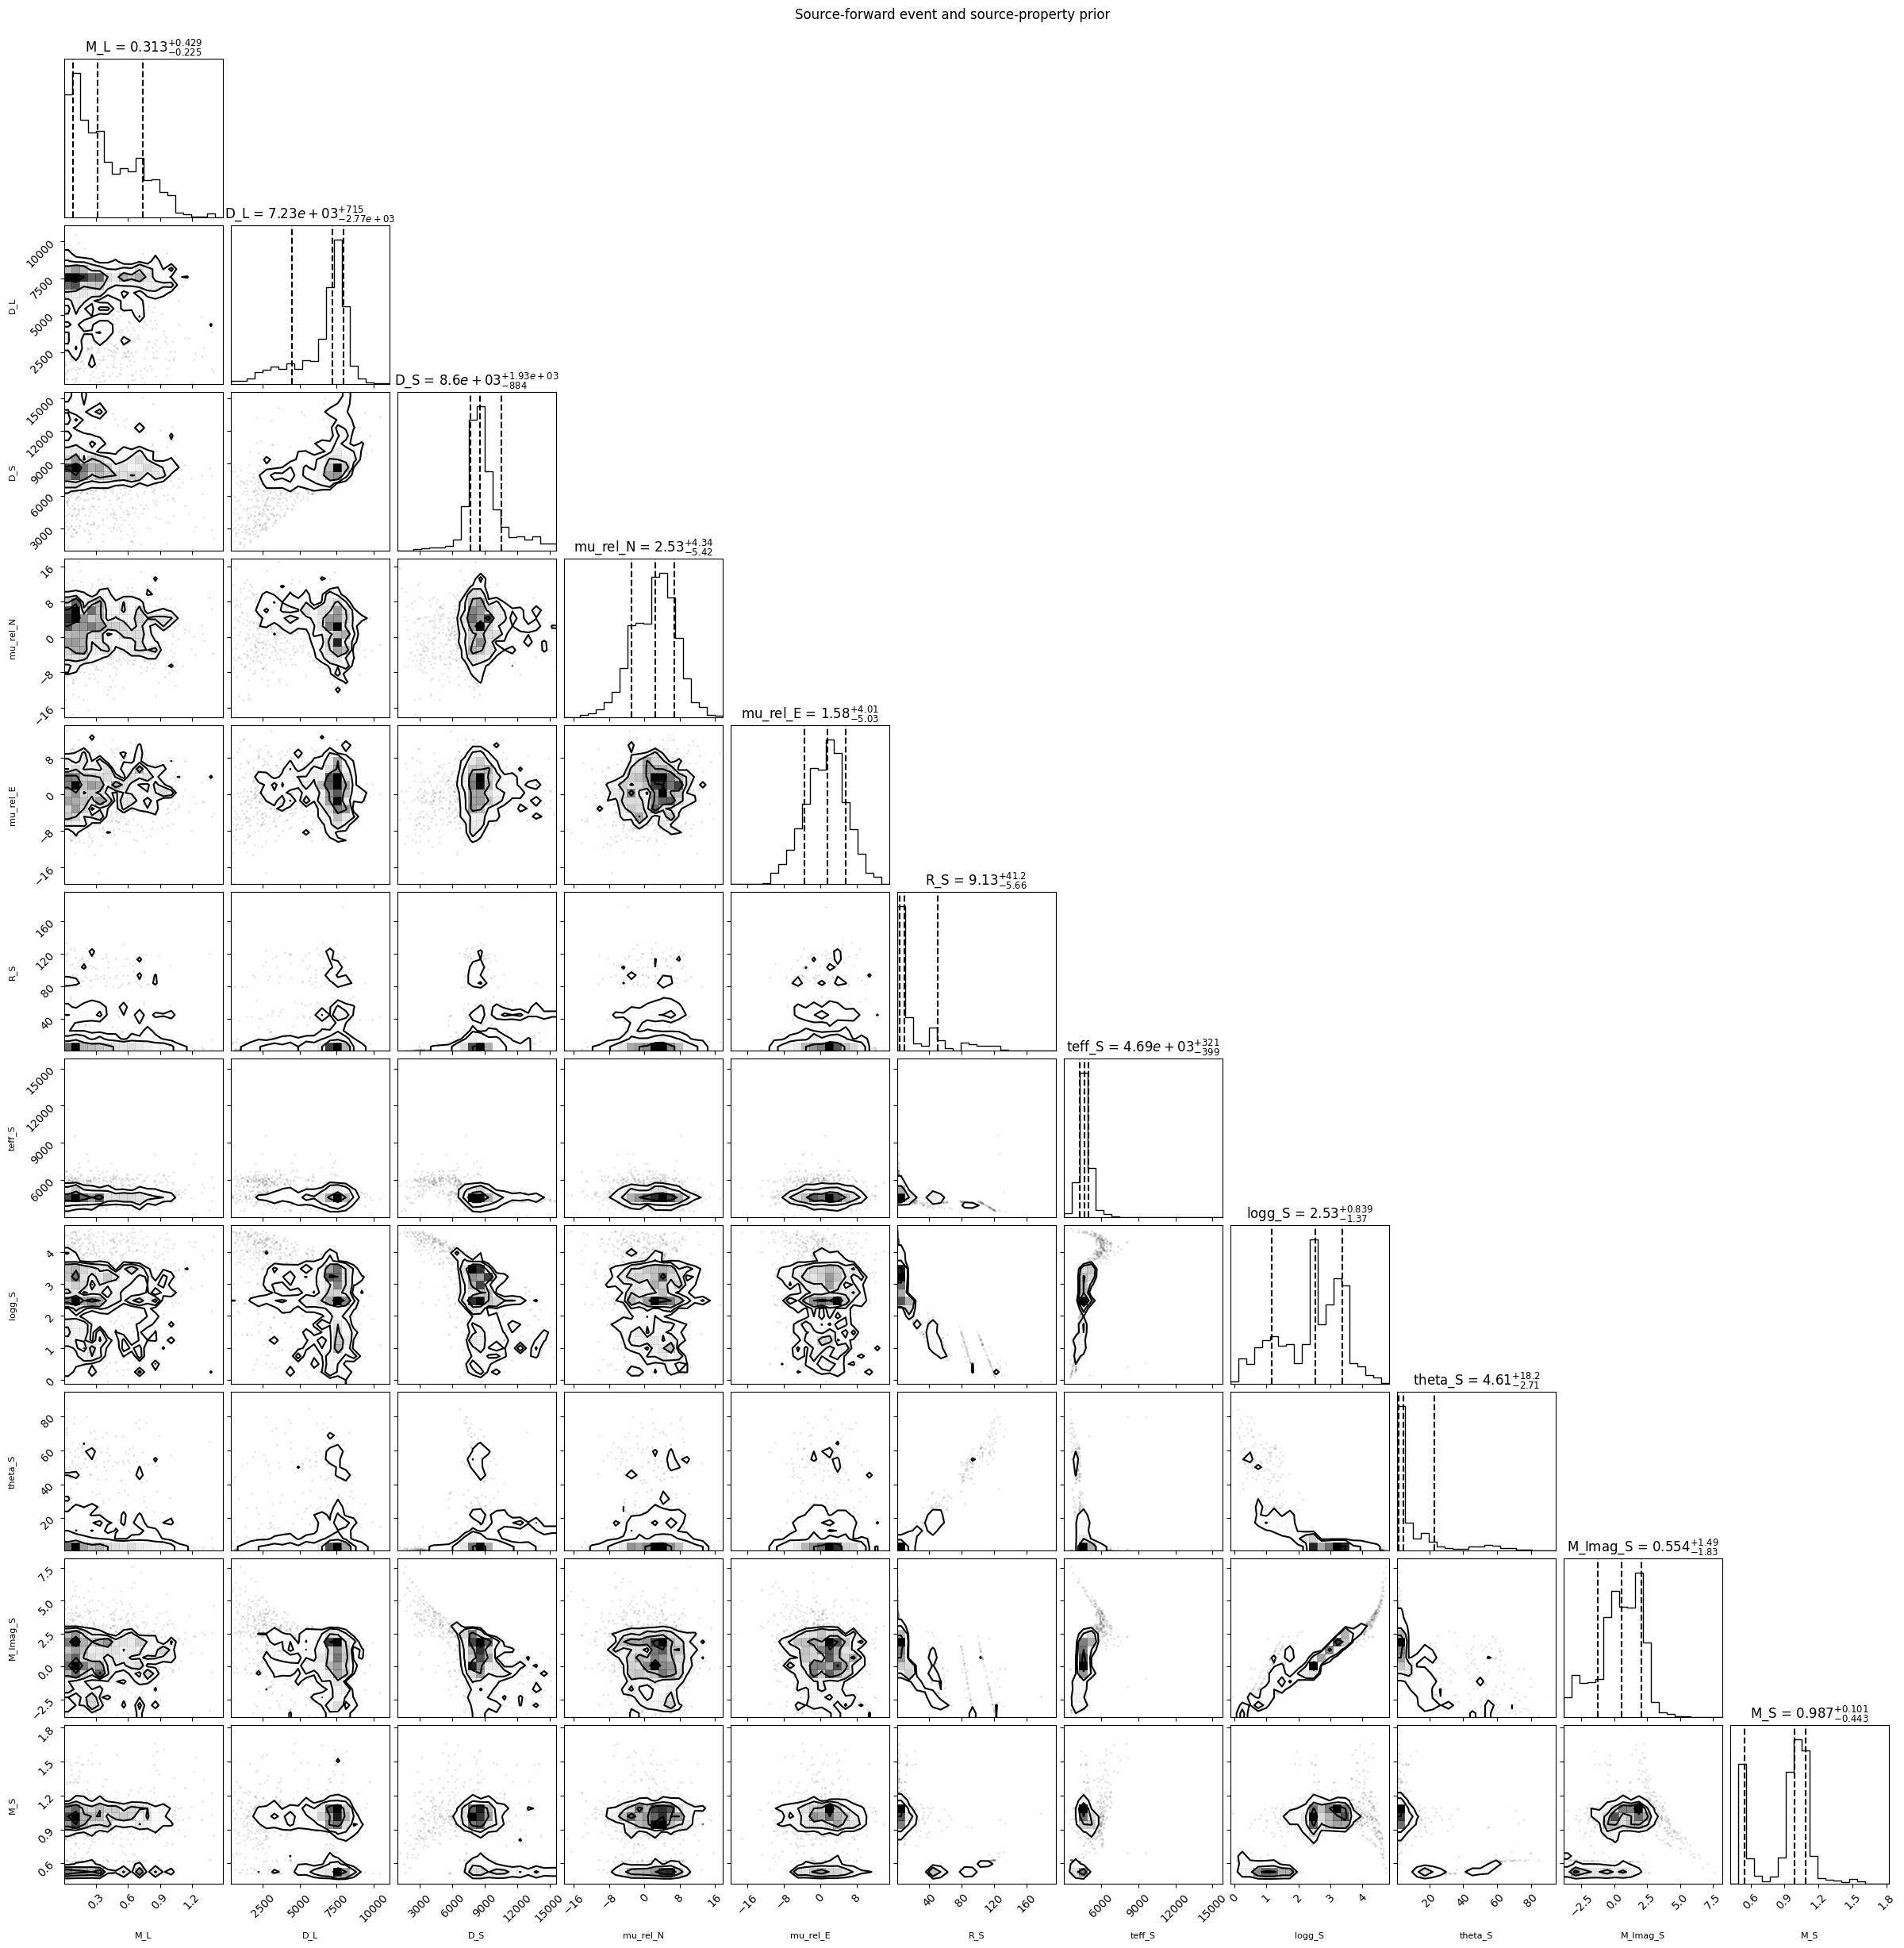

In [6]:
full_corner_columns = corner_columns + [
    "R_S",
    "teff_S",
    "logg_S",
    "theta_S",
    "M_Imag_S",
    "M_S"
]

full_df = df_forward.loc[finite_source].copy()
full_df = event_corner_frame(full_df)

# Keep the smoke notebook responsive while preserving deterministic sampling.
if len(full_df) > 1_200:
    full_df = full_df.sample(n=1_200, random_state=SEED)

try:
    import corner

    fig = corner.corner(
        full_df[full_corner_columns].to_numpy(),
        labels=full_corner_columns,
        weights=full_df["wtj"].to_numpy(),
        quantiles=[0.16, 0.50, 0.84],
        show_titles=True,
        title_fmt=".3g",
        label_kwargs={"fontsize": 8},
    )
except ImportError:
    axes = pd.plotting.scatter_matrix(
        full_df[full_corner_columns],
        figsize=(14, 14),
        diagonal="hist",
        alpha=0.05,
    )
    fig = axes[0, 0].figure

fig.suptitle("Source-forward event and source-property prior", y=1.01)
plt.show()



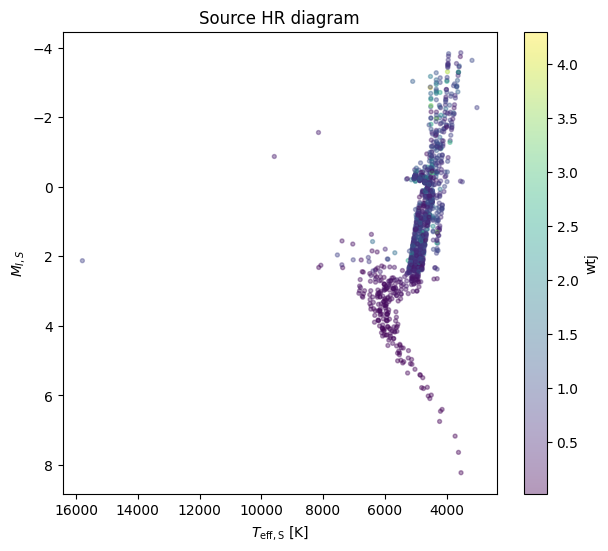

In [7]:
hr_df = full_df[
    np.isfinite(full_df["teff_S"]) &
    np.isfinite(full_df["M_Imag_S"])
].copy()

fig, ax = plt.subplots(figsize=(7, 6))

sc = ax.scatter(
    hr_df["teff_S"],
    hr_df["M_Imag_S"],
    c=hr_df["wtj"],
    s=8,
    alpha=0.4,
)

ax.invert_xaxis()  
ax.invert_yaxis() 

ax.set_xlabel(r"$T_{\rm eff,S}$ [K]")
ax.set_ylabel(r"$M_{I,S}$")
ax.set_title("Source HR diagram")

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("wtj")

plt.show()